In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [59]:
df = pd.read_csv('/content/kaggle_survey_2017_2021.csv', header=1)
df.head()

,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,Select the title most similar to your current role (or most recent title if retired): - Selected Choice,For how many years have you been writing code and/or programming?,What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,...,"In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Neptune.ai","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Weights & Biases","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Comet.ml","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Sacred + Omniboard","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - TensorBoard","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Guild.ai","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Polyaxon","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Domino Model Monitor","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None","In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other"
0,2021,910.0,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,784.0,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,924.0,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
3,2021,575.0,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,781.0,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
df.shape

(106301, 293)

In [61]:
df.columns

Index(['Year', 'Duration (in seconds)', 'What is your age (# years)?',
       'What is your gender? - Selected Choice',
       'In which country do you currently reside?',
       'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?',
       'Select the title most similar to your current role (or most recent title if retired): - Selected Choice',
       'For how many years have you been writing code and/or programming?',
       'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python',
       'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R',
       ...
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Neptune.ai ',
       'In the next 2 years, do you hope to become more familiar with any of these tools for ma

In [62]:
rename_dict = {
    'Duration (in seconds)': 'Duration',
    'What is your age (# years)?': 'Age',
    'What is your gender? - Selected Choice': 'Gender',
    'In which country do you currently reside?': 'Country',
    'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?': 'Education',
    'Select the title most similar to your current role (or most recent title if retired): - Selected Choice': 'JobTitle',
    'For how many years have you been writing code and/or programming?': 'CodingExperience',
    'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python': 'Lang_Python',
    'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R': 'Lang_R',
}
df = df.rename(columns=rename_dict)

In [63]:
df.columns

Index(['Year', 'Duration', 'Age', 'Gender', 'Country', 'Education', 'JobTitle',
       'CodingExperience', 'Lang_Python', 'Lang_R',
       ...
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Neptune.ai ',
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Weights & Biases ',
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Comet.ml ',
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Sacred + Omniboard ',
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that ap

In [64]:
important_cols = ['Year', 'Duration', 'Age', 'Gender', 'Country',
                  'Education', 'JobTitle', 'CodingExperience',
                  'Lang_Python', 'Lang_R']

df_small = df[important_cols]
df_small.head()

,Year,Duration,Age,Gender,Country,Education,JobTitle,CodingExperience,Lang_Python,Lang_R
0,2021,910.0,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R
1,2021,784.0,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN
2,2021,924.0,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN
3,2021,575.0,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN
4,2021,781.0,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN


In [65]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106301 entries, 0 to 106300
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Year              106301 non-null  int64  
 1   Duration          89585 non-null   float64
 2   Age               105856 non-null  object 
 3   Gender            106206 non-null  object 
 4   Country           106180 non-null  object 
 5   Education         103318 non-null  object 
 6   JobTitle          99087 non-null   object 
 7   CodingExperience  92785 non-null   object 
 8   Lang_Python       65942 non-null   object 
 9   Lang_R            20884 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 8.1+ MB


In [66]:
df_small['Education'].value_counts()

,count
Education,
Masterâ€™s degree,37395
Bachelorâ€™s degree,29961
Doctoral degree,13568
Master's degree,6273
Bachelor's degree,4811
Some college/university study without earning a bachelorâ€™s degree,4631
Professional degree,2360
I prefer not to answer,1794
No formal education past high school,1122


In [69]:
df_small['Education'] = df_small['Education'].str.replace("â€™", "'", regex=False)

df_small['Education'] = df_small['Education'].str.strip()

In [70]:
df_small['Education'].value_counts()

,count
Education,
Master's degree,43668
Bachelor's degree,34772
Doctoral degree,13568
Some college/university study without earning a bachelor's degree,5417
Professional degree,2360
I prefer not to answer,1794
No formal education past high school,1122
Professional doctorate,360
I did not complete any formal education past high school,257


In [71]:
df_small['Gender'].value_counts()

,count
Gender,
Male,49178
Man,36387
Female,10000
Woman,8768
Prefer not to say,1276
Prefer to self-describe,224
A different identity,159
Nonbinary,140
"Non-binary, genderqueer, or gender non-conforming",74


In [72]:
gender_map = {
    'Man': 'Male',
    'Male': 'Male',
    'Woman': 'Female',
    'Female': 'Female',
    'Nonbinary': 'Non-binary',
    'Non-binary, genderqueer, or gender non-conforming': 'Non-binary',
    'Prefer to self-describe': 'Other',
    'A different identity': 'Other',
    'Prefer not to say': 'Prefer not to say'
}

df_small['Gender'] = df['Gender'].replace(gender_map)

In [73]:
df_small['Gender'].value_counts()

,count
Gender,
Male,85565
Female,18768
Prefer not to say,1276
Other,383
Non-binary,214


In [74]:
df_small.head()

,Year,Duration,Age,Gender,Country,Education,JobTitle,CodingExperience,Lang_Python,Lang_R
0,2021,910.0,50-54,Male,India,Bachelor's degree,Other,5-10 years,Python,R
1,2021,784.0,50-54,Male,Indonesia,Master's degree,Program/Project Manager,20+ years,NaN,NaN
2,2021,924.0,22-24,Male,Pakistan,Master's degree,Software Engineer,1-3 years,Python,NaN
3,2021,575.0,45-49,Male,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN
4,2021,781.0,45-49,Male,India,Doctoral degree,Other,< 1 years,Python,NaN


In [76]:
df_small.Lang_Python.value_counts()

,count
Lang_Python,
Python,65942


In [77]:
df_small['Lang_Python'] = df_small['Lang_Python'].notna().map({True: 'Yes', False: 'No'})
df_small['Lang_Python'].value_counts()

,count
Lang_Python,
Yes,65942
No,40359


In [79]:
df_small.Lang_R.value_counts()

,count
Lang_R,
R,20884


In [80]:
df_small['Lang_R'] = df_small['Lang_R'].notna().map({True: 'Yes', False: 'No'})
df_small['Lang_R'].value_counts()

,count
Lang_R,
No,85417
Yes,20884


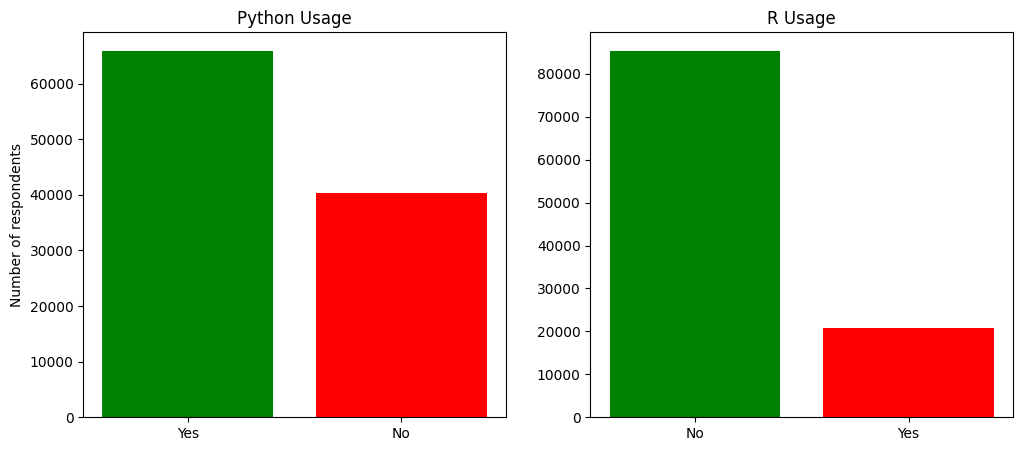

In [82]:
python_counts = df_small['Lang_Python'].value_counts()
r_counts = df_small['Lang_R'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].bar(python_counts.index, python_counts.values, color=['green', 'red'])
ax[0].set_title("Python Usage")
ax[0].set_ylabel("Number of respondents")

ax[1].bar(r_counts.index, r_counts.values, color=['green', 'red'])
ax[1].set_title("R Usage")

plt.show()


In [84]:
df_small.head()

,Year,Duration,Age,Gender,Country,Education,JobTitle,CodingExperience,Lang_Python,Lang_R
0,2021,910.0,50-54,Male,India,Bachelor's degree,Other,5-10 years,Yes,Yes
1,2021,784.0,50-54,Male,Indonesia,Master's degree,Program/Project Manager,20+ years,No,No
2,2021,924.0,22-24,Male,Pakistan,Master's degree,Software Engineer,1-3 years,Yes,No
3,2021,575.0,45-49,Male,Mexico,Doctoral degree,Research Scientist,20+ years,Yes,No
4,2021,781.0,45-49,Male,India,Doctoral degree,Other,< 1 years,Yes,No


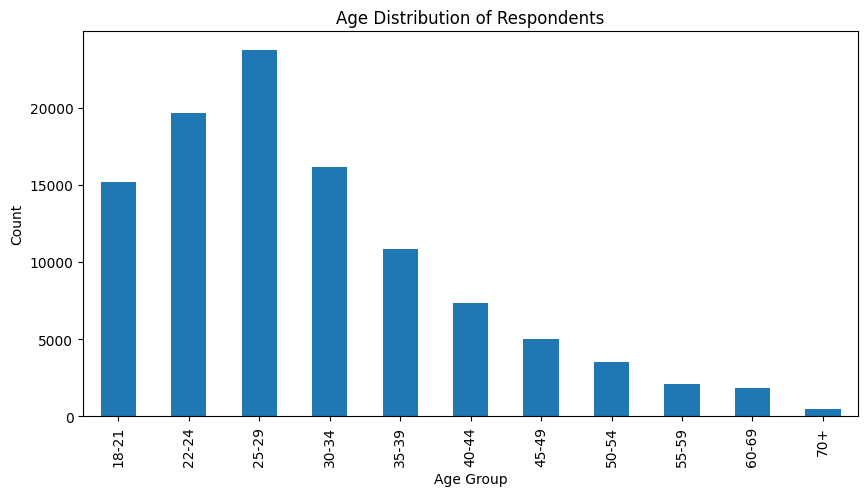

In [85]:
import matplotlib.pyplot as plt

df_small['Age'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title("Age Distribution of Respondents")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


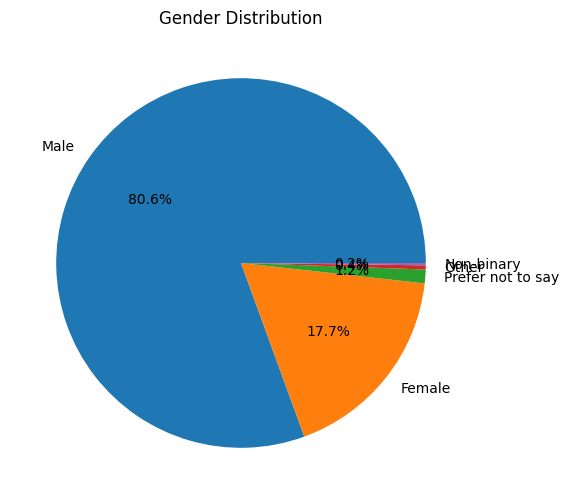

In [88]:
df_small['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()


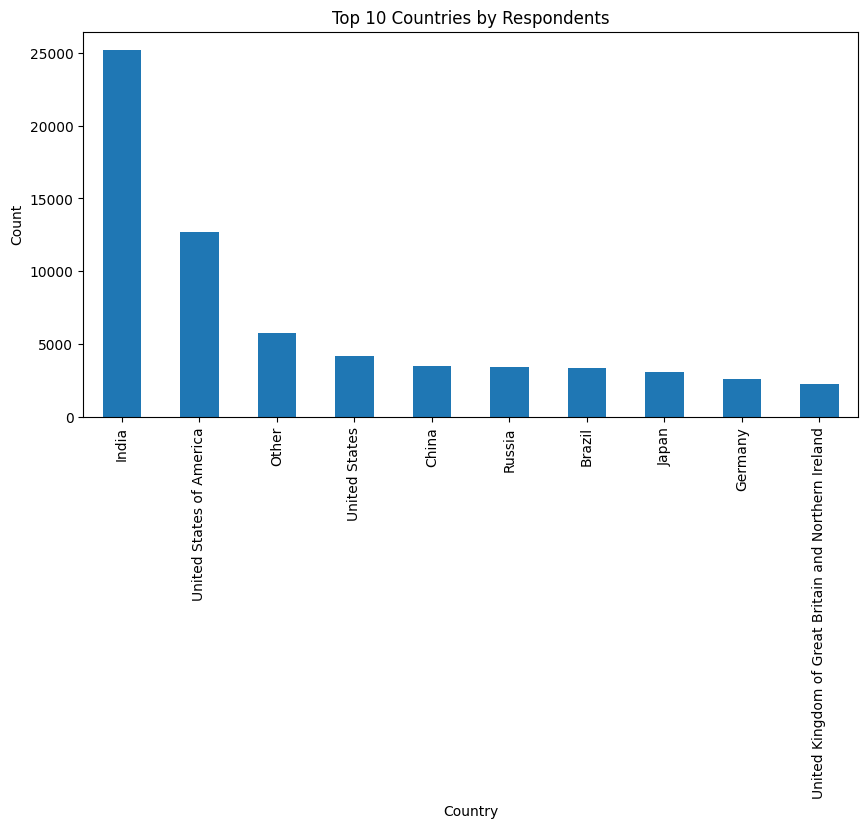

In [89]:
df_small['Country'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Respondents")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


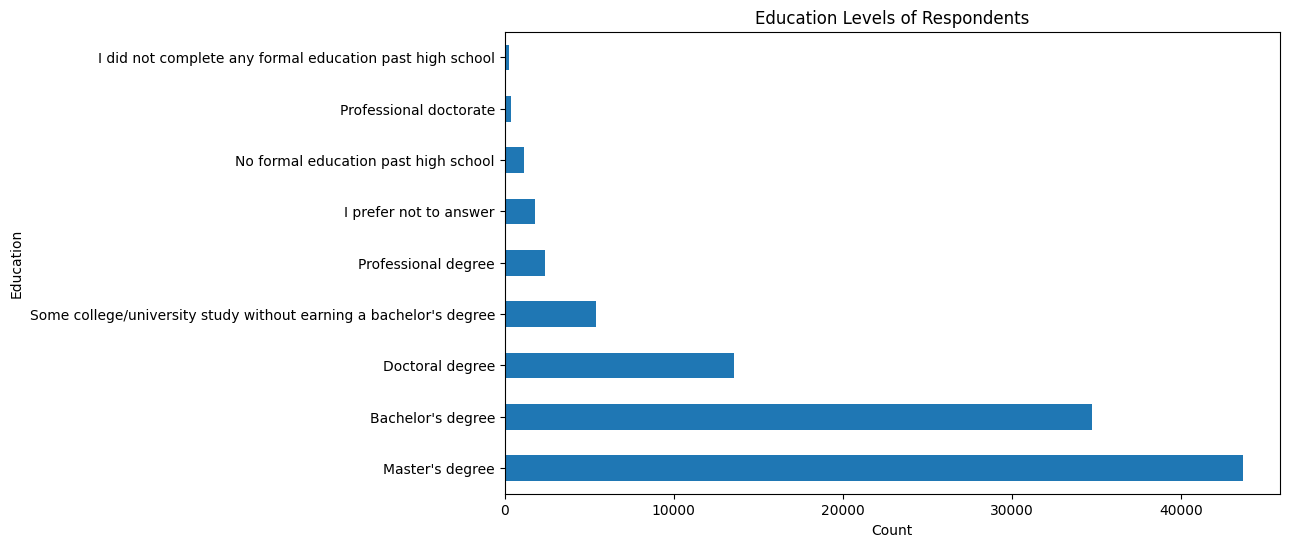

In [90]:
df_small['Education'].value_counts().plot(kind='barh', figsize=(10,6))
plt.title("Education Levels of Respondents")
plt.xlabel("Count")
plt.ylabel("Education")
plt.show()


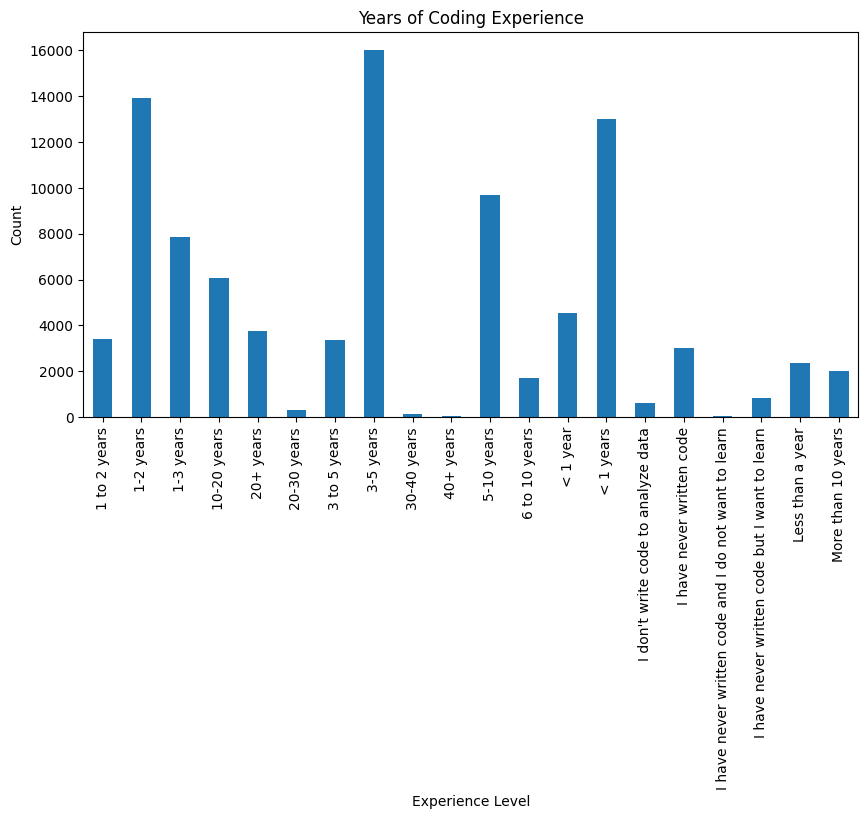

In [93]:
df_small['CodingExperience'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title("Years of Coding Experience")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.show()


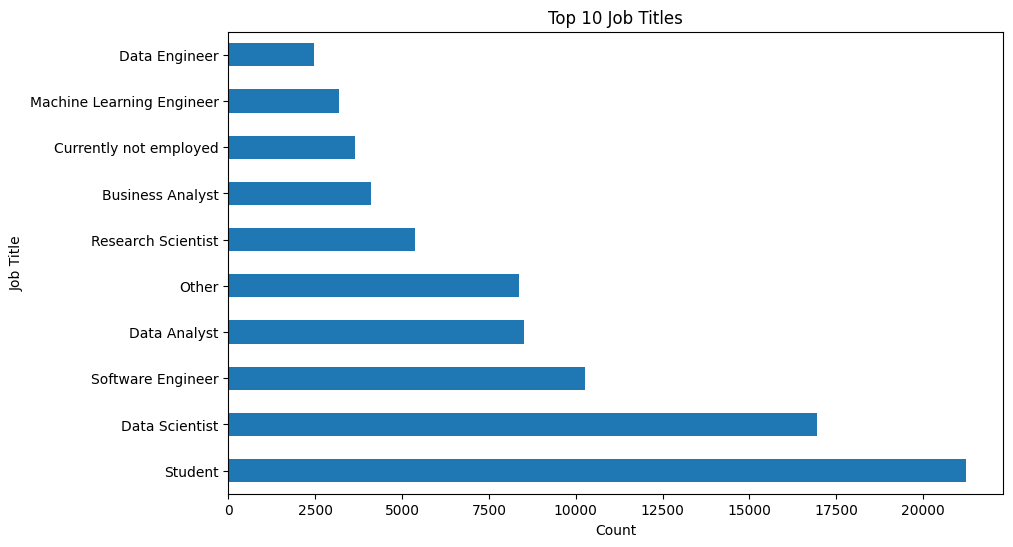

In [94]:
df_small['JobTitle'].value_counts().head(10).plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()
